# Laboratorio 5 - Naive Bayes

Este notebook cubre los primeros cuatro incisos del laboratorio:

1. Construir un modelo de regresion con Naive Bayes para predecir `price`.
2. Evaluar que tan bien funciona usando metricas correctas de regresion.
3. Comparar Naive Bayes contra regresion lineal y arbol de regresion.
4. Construir un modelo de clasificacion usando la categoria de precio.

## Estructura

1. Imports y configuracion
2. Carga de datos
3. Preparacion de datos
4. Inciso 1: modelo de regresion con Naive Bayes
5. Inciso 2: evaluacion del modelo
6. Inciso 3: comparacion con regresion lineal y arbol de regresion
7. Inciso 4: modelo de clasificacion con categoria de precio

In [12]:
%pip install pyreadr pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


## Imports y Configuracion

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyreadr
import seaborn as sns
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor

DATA_PATH = Path("listings.RData")
RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## Carga de Datos

Cargamos el archivo `listings.RData` y verificamos el objeto principal.

In [14]:
result = pyreadr.read_r(DATA_PATH)
print("Objetos encontrados en el RData:")
print(list(result.keys()))

df = result["listings"].copy()
print(f"Dimensiones del DataFrame: {df.shape}")
display(df.head())

Objetos encontrados en el RData:
['listings']
Dimensiones del DataFrame: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,https://www.airbnb.com/users/show/8028,Sylvia,2009-02-16,"Austin, TX",I am a licensed Real Estate Broker and owner o...,within a few hours,100%,90%,t,https://a0.muscache.com/im/users/8028/profile_...,https://a0.muscache.com/im/users/8028/profile_...,East Downtown,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78702,NaN,30.26057,-97.73441,Entire guesthouse,Entire home/apt,3,1.0,1 bath,1,2,"[""Iron"", ""Private entrance"", ""Hot water"", ""Dis...",$97.00,2,90,2,4,90,90,2.1,90.0,NaN,t,13,35,65,328,2025-09-17,708,25,1,81,33,150,14550,2009-03-19,2025-09-02,4.85,4.88,4.86,4.90,4.82,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,https://www.airbnb.com/users/show/14156,Amy,2009-04-20,"Austin, TX","We are a family of four (with teenagers, all o...",within an hour,100%,96%,t,https://a0.muscache.com/im/users/14156/profile...,https://a0.muscache.com/im/users/14156/profile...,Zilker,1,2,"['email', 'phone']",t,t,Neighborhood highlights,78704,NaN,30.26034,-97.76487,Entire guesthouse,Entire home/apt,2,1.0,1 bath,1,2,"[""Private patio or balcony"", ""Stove"", ""Cleanin...",$160.00,3,365,3,3,1125,1125,3.0,1125.0,NaN,t,12,30,50,316,2025-09-17,339,14,1,61,20,84,13440,2011-09-06,2025-08-20,4.97,4.97,4.96,4.99,4.98,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,https://www.airbnb.com/users/show/25298,Karen,2009-07-11,"Austin, TX",I handle the reservations at the studio on the...,within a day,100%,60%,f,https://a0.muscache.com/im/users/25298/profile...,https://a0.muscache.com/im/users/25298/profile...,East Riverside,1,1,"['email', 'phone']",t,f,,78741,NaN,30.23466,-97.73682,Entire guest suite,Entire home/apt,2,1.0,1 bath,1,1,"[""Wifi"", ""Smoke alarm"", ""Shampoo"", ""Heating"", ...",$38.00,4,90,3,14,90,90,6.0,90.0,NaN,t,29,59,88,88,2025-09-17,54,1,0,88,2,8,304,2010-02-19,2025-05-05,4.57,4.55,4.6

## Preparacion de Datos

Para esta primera parte trabajaremos con predictores numericos. Tambien limpiamos la variable `price`, excluimos identificadores y preparamos el mismo `train/test split` que se usara para comparar los modelos de regresion.

In [15]:
def clean_price(series: pd.Series) -> pd.Series:
    cleaned = (
        series.astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    cleaned = cleaned.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")


df["price_num"] = clean_price(df["price"])

excluded_features = {
    "price_num",
    "id",
    "scrape_id",
    "host_id",
    "estimated_occupancy_l365d",
}

feature_columns = [
    column
    for column in df.select_dtypes(include="number").columns
    if column not in excluded_features
]

df_model = df[feature_columns + ["price_num"]].dropna(subset=["price_num"]).copy()

X = df_model[feature_columns]
y_price = df_model["price_num"]
y_log = np.log1p(y_price)

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

print(f"Filas para modelar: {len(df_model):,}")
print(f"Predictores numericos usados: {len(feature_columns)}")
print("\nVariables predictoras:")
print(feature_columns)

display(y_price.describe().to_frame(name="price_num"))

Filas para modelar: 76,246
Predictores numericos usados: 29

Variables predictoras:
['latitude', 'longitude', 'accommodates', 'bathrooms', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms', 'reviews_per_month']


/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,price_num
count,76246.000000
mean,750.509220
std,4250.606945
min,8.000000
25%,120.000000
50%,193.000000
75%,326.000000
max,50123.000000


## Inciso 1

Como `scikit-learn` no incluye un regresor de Naive Bayes nativo, implementamos una version generativa sencilla:

- la respuesta es `log(1 + price)`,
- cada predictor numerico se asume condicionalmente independiente dado el precio,
- cada predictor se modela con una gaussiana cuya media depende linealmente de la respuesta.

In [16]:
class GaussianNaiveBayesRegressor:
    def __init__(self, epsilon: float = 1e-6):
        self.epsilon = epsilon

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        self.mu_y_ = y.mean()
        self.var_y_ = max(y.var(ddof=1), self.epsilon)

        y_centered = y - self.mu_y_
        x_means = X.mean(axis=0)
        cov_xy = (y_centered[:, None] * (X - x_means)).sum(axis=0) / max(len(y) - 1, 1)

        self.beta_ = cov_xy / self.var_y_
        self.alpha_ = x_means - self.beta_ * self.mu_y_

        residuals = X - (self.alpha_[None, :] + np.outer(y, self.beta_))
        self.sigma2_ = residuals.var(axis=0, ddof=1)
        self.sigma2_ = np.where(self.sigma2_ < self.epsilon, self.epsilon, self.sigma2_)

        self.posterior_precision_ = (1.0 / self.var_y_) + np.sum((self.beta_ ** 2) / self.sigma2_)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        posterior_mean_num = (self.mu_y_ / self.var_y_) + np.sum(
            (self.beta_ * (X - self.alpha_)) / self.sigma2_,
            axis=1,
        )
        return posterior_mean_num / self.posterior_precision_


nb_regressor = GaussianNaiveBayesRegressor()
nb_regressor.fit(X_train_imp, y_train_log)

y_pred_log = nb_regressor.predict(X_test_imp)
y_pred_price = np.clip(np.expm1(y_pred_log), 0, None)
y_test_price = np.expm1(y_test_log)

results_df = pd.DataFrame(
    {
        "price_real": y_test_price.values,
        "price_predicho": y_pred_price,
    }
)
results_df["error_abs"] = (results_df["price_real"] - results_df["price_predicho"]).abs()

display(results_df.sample(10, random_state=RANDOM_STATE))

,price_real,price_predicho,error_abs
3669,255.0,148.621825,106.378175
14788,955.0,1095.032413,140.032413
12496,198.0,190.606967,7.393033
3781,165.0,199.881576,34.881576
15209,152.0,94.630551,57.369449
14407,336.0,469.138617,133.138617
8881,239.0,384.033997,145.033997
11524,302.0,1588.230762,1286.230762
1606,277.0,363.636247,86.636247
10447,192.0,285.006115,93.006115


## Inciso 2

Evaluamos el modelo con `MAE`, `RMSE` y `R2`, y lo comparamos con un baseline que siempre predice el precio promedio.

,modelo,MAE,RMSE,R2
0,Naive Bayes Regresion,645.2536,4345.1166,-0.0135
1,Baseline promedio,1017.7531,4316.1287,0.0000


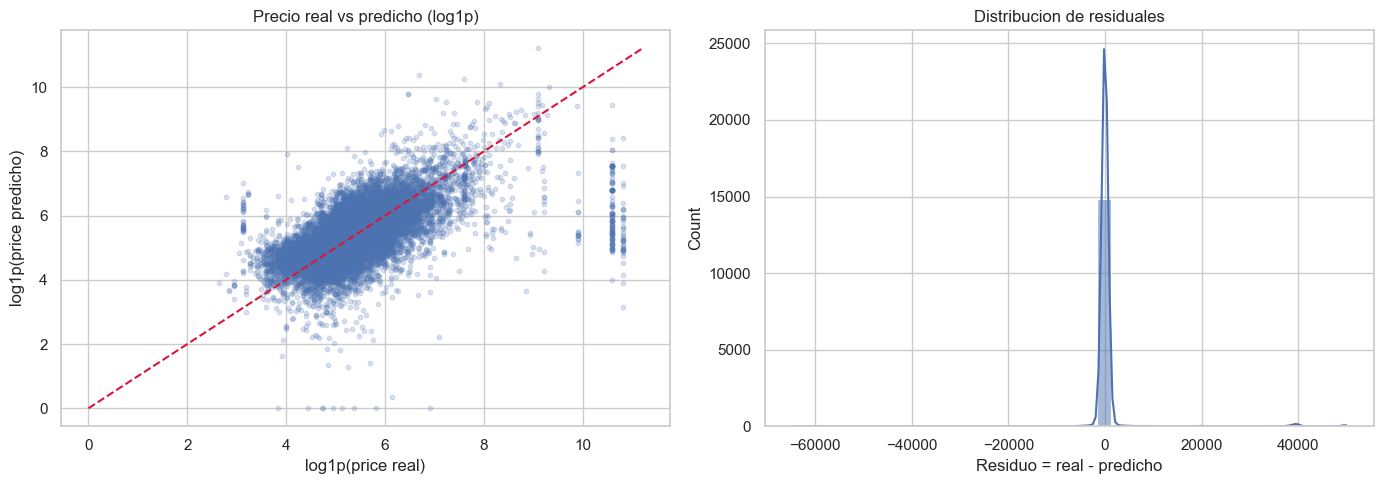

In [17]:
baseline_pred = np.repeat(y_test_price.mean(), len(y_test_price))

metrics_df = pd.DataFrame(
    {
        "modelo": ["Naive Bayes Regresion", "Baseline promedio"],
        "MAE": [
            mean_absolute_error(y_test_price, y_pred_price),
            mean_absolute_error(y_test_price, baseline_pred),
        ],
        "RMSE": [
            mean_squared_error(y_test_price, y_pred_price) ** 0.5,
            mean_squared_error(y_test_price, baseline_pred) ** 0.5,
        ],
        "R2": [
            r2_score(y_test_price, y_pred_price),
            r2_score(y_test_price, baseline_pred),
        ],
    }
)

display(metrics_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_plot = np.log1p(y_test_price)
y_plot = np.log1p(y_pred_price)
axis_min = min(x_plot.min(), y_plot.min())
axis_max = max(x_plot.max(), y_plot.max())

axes[0].scatter(x_plot, y_plot, alpha=0.20, s=10)
axes[0].plot([axis_min, axis_max], [axis_min, axis_max], color="crimson", linestyle="--")
axes[0].set_title("Precio real vs predicho (log1p)")
axes[0].set_xlabel("log1p(price real)")
axes[0].set_ylabel("log1p(price predicho)")

residuals = y_test_price - y_pred_price
sns.histplot(residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Distribucion de residuales")
axes[1].set_xlabel("Residuo = real - predicho")

plt.tight_layout()
plt.show()

### Interpretacion Inicial

Con esta configuracion, Naive Bayes mejora el `MAE` frente al baseline, pero mantiene un `RMSE` alto y un `R2` ligeramente negativo. Eso sugiere que puede capturar parte del comportamiento de precios tipicos, pero le cuesta mucho modelar propiedades con precios extremos.

## Inciso 3

Ahora comparamos el modelo de Naive Bayes contra:

- regresion lineal,
- arbol de regresion.

La comparacion se hace bajo las mismas condiciones:

- mismo conjunto de entrenamiento y prueba,
- mismas variables predictoras,
- misma imputacion de faltantes,
- misma transformacion `log(1 + price)` para entrenar.

In [18]:
regression_models = {
    "Naive Bayes Regresion": GaussianNaiveBayesRegressor(),
    "Regresion Lineal": LinearRegression(),
    "Arbol de Regresion": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=12,
        min_samples_leaf=20,
    ),
}

comparison_rows = []

for model_name, model in regression_models.items():
    model.fit(X_train_imp, y_train_log)
    pred_price = np.clip(np.expm1(model.predict(X_test_imp)), 0, None)
    comparison_rows.append(
        {
            "modelo": model_name,
            "MAE": mean_absolute_error(y_test_price, pred_price),
            "RMSE": mean_squared_error(y_test_price, pred_price) ** 0.5,
            "R2": r2_score(y_test_price, pred_price),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE").reset_index(drop=True)
best_regression_model = comparison_df.loc[0, "modelo"]

display(comparison_df.round(4))
print(f"Mejor modelo segun RMSE: {best_regression_model}")

/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/homebrew/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,modelo,MAE,RMSE,R2
0,Arbol de Regresion,401.3676,3035.9254,0.5052
1,Naive Bayes Regresion,645.2536,4345.1166,-0.0135
2,Regresion Lineal,599.0159,4473.1385,-0.0741


Mejor modelo segun RMSE: Arbol de Regresion


### Lectura del Inciso 3

Con los resultados obtenidos en este notebook, el **arbol de regresion** es el que mejor funciona para predecir el precio, porque obtiene el menor `RMSE`, el menor `MAE` y el mejor `R2`.

Tambien se observa que:

- la regresion lineal tiene un `MAE` algo mejor que Naive Bayes, pero peor `RMSE` y peor `R2`,
- Naive Bayes supera a la regresion lineal en `RMSE`, pero sigue lejos del arbol de regresion,
- el arbol parece adaptarse mucho mejor a relaciones no lineales del precio.

## Inciso 4

Como en el dataset no existe una columna ya creada para `barata`, `media` y `cara`, construiremos esa variable categorizando `price` en tres grupos usando terciles.

Para evitar fuga de informacion, los puntos de corte se calculan **solo con el conjunto de entrenamiento** y luego se aplican tambien al conjunto de prueba.

In [19]:
train_price_for_bins = y_price.loc[X_train.index]
q1, q2 = train_price_for_bins.quantile([1 / 3, 2 / 3])

df_model["price_category"] = pd.cut(
    df_model["price_num"],
    bins=[-np.inf, q1, q2, np.inf],
    labels=["barata", "media", "cara"],
    include_lowest=True,
)

y_class = df_model["price_category"]
y_train_class = y_class.loc[X_train.index]
y_test_class = y_class.loc[X_test.index]

print(f"Corte 1 (barata/media): {q1:.2f}")
print(f"Corte 2 (media/cara): {q2:.2f}")

display(y_class.value_counts().to_frame(name="conteo"))

Corte 1 (barata/media): 142.00
Corte 2 (media/cara): 269.00


,conteo
price_category,
media,25585
barata,25414
cara,25247


In [20]:
classification_imputer = SimpleImputer(strategy="median")
X_train_cls_imp = classification_imputer.fit_transform(X_train)
X_test_cls_imp = classification_imputer.transform(X_test)

nb_classifier = GaussianNB()
nb_classifier.fit(X_train_cls_imp, y_train_class)

y_pred_class = nb_classifier.predict(X_test_cls_imp)

classification_preview = pd.DataFrame(
    {
        "categoria_real": y_test_class.values,
        "categoria_predicha": y_pred_class,
    }
)

display(classification_preview.head(15))

/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/opt/homebrew/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


,categoria_real,categoria_predicha
0,media,barata
1,cara,barata
2,barata,barata
3,barata,barata
4,media,barata
5,cara,barata
6,media,barata
7,media,barata
8,barata,barata
9,barata,barata
